# Анализ закономерностей определяющих успешность игр для интернет-магазина.

Интернет-магазин продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

1. [Загрузка файла с данными и анализ общей информации](#start)
2. [Подготовка данных](#preprocessing)
    * [Преобазование типов данных и регистра](#transformation)
    * [Обработка пропусков](#skip)
    * [Добавление столбца с суммарными продажами во всех регионах](#total_sales)
3. [Исследовательский анализ данных](#analys)
    * [Динамика выпуска и продаж игр по годам](#count_years)
    * [Анализ сроков существавания платформ и платформы с наибольшими продажами ](#platform_period)
    * [Установление актуального периода](#act_period)
    * [Анализ динамики продаж за актуальный период](#act_period_analys)
4. [Портрет пользователя каждого региона](#portrait)
5. [Проверка гипотез](#hypothesis)
    * [Гипотеза 1: средние пользовательские рейтинги платформ Xbox One и PC одинаковые¶](#hypothesis_one)
    * [Гипотеза 2: средние пользовательские рейтинги жанров Action  и Sports  разные](#hypothesis_two) 
6. [Общий вывод](#conclusion)

## Загрузка файла с данными и анализ общей информации <a id="start"></a> 

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st
import os

In [2]:
pth1 = 'games.csv'
pth2 = '/datasets/games.csv'
if os.path.exists(pth1):
    games = pd.read_csv(pth1)
elif os.path.exists(pth2):
    games = pd.read_csv(pth2)
else:
    print("Проверьте правильность пути к датасету")
games.info()
games.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


## Подготовка данных <a id="preprocessing"></a> 

### Преобазование типов данных и регистра <a id="transformation"></a> 

In [3]:
#приводим названия столбцов к нижнему регистру
games.columns = games.columns.str.lower()

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Молодец! 👍 Не которые пишут длинный словарь для замены колонок.</font>

In [4]:
#преобразуем типы данные
games['year_of_release'] = games['year_of_release'].astype(int, errors='ignore')
games['user_score'] = games['user_score'].astype(float, errors='ignore')

games.info()
games.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Заменить типы данных необходиом в двух столбцах - 'year_of_release' (float заменяем на int, т.к. год может быть только целым числом) и 'user_score' (на float, т.к. оценка может быть вещественным числом). Заменить даные не получатеся из-за наличия пропусков в столбцах, после обработки пропусков выполним замену типа данных еще раз. 

Формат даты для 'year_of_release' использовать не целесообразно - в данных информация есть только о годе релиза игры.

### Обработка пропусков <a id="skip"></a> 

In [5]:
#обработка пропусков
games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [6]:
#пропуски в столбце 'name'
display(games.loc[games['name'].isna()])
#удаляем строки с пропусками
games.drop([659, 14244], inplace=True)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


По играм с пропусками в столбце 'name' есть также пропуски в столбцах: 'genre' и 'critic_score', 'user_score',	'rating'. Поэтому эти данные нужно удалить. 

In [7]:
#пропуски в столбце 'year_of_release'
display(games.loc[games['year_of_release'].isna()])

#извлекаем год из названия игры
year_skip = games.loc[games['year_of_release'].isna()]['name'].str.extract(r'(\d{4})', expand=False)
#проверяем полученные значения
display(year_skip.unique())

#заменяем пропуски полученными значениями             
games['year_of_release'].fillna(year_skip, inplace=True)

#удаляем строки с пропущенным годом выпуска и меням тип данных
games.dropna(subset=['year_of_release'], inplace=True)
games['year_of_release'] = games['year_of_release'].astype(int, errors='ignore')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,tbd,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


array(['2004', nan, '2006', '2003', '2009', '2002', '2013', '2005',
       '2011', '2008', '2007'], dtype=object)

В названии некоторых игр есть год выпуска этой игры. Этими данными можно заполнить пропуски. Таких значений 17. 
Год выпуска игры является важным параметром по которому мы будем фильтровать данные для прогноза, поэтому данные без года выпуска нужно удалить.

In [8]:
#пропуски в столбцах 'critic_score', 'user_score', 'rating'
temp = games.isnull()[['critic_score', 'user_score', 'rating']].sum()
print(temp.div(games['name'].count()).round(2))
print(
    'Количество игр с оценкой пользователей tbd -', 
    (games.query('user_score == "tbd"')['name'].count()/games['name'].count()).round(2)
)

#заменяем 'tbd' на пропуски
games['user_score'].replace('tbd', np.nan, inplace=True)
games['user_score'] = games['user_score'].astype(float)

#замена пропусков в столбце 'rating'
games['rating'].fillna('no_rating', inplace=True)

critic_score    0.51
user_score      0.40
rating          0.41
dtype: float64
Количество игр с оценкой пользователей tbd - 0.14


В столбцах 'critic_score', 'user_score', 'rating' очень большое количество пропусков (40%-50%). Удаление данных с пропусками приведет к большой потере данных. Заполнение рассчетными значениями (средними или медианными) может привести к искажению выводов (из-за большой доли пропусков). Поэтому в столбцах 'critic_score' и 'user_score' оставляем пропуски и учитываем при анализе даных наличие пропусков в даных столбцах.

В столбце 'rating' данные имеют формат "object", поэтому можно заменить пропуски на значение "no_rating". Это позволит при группировке значений не потерять эту группу данных.

В столбце с оценкой пользователей встречается аббревиатура 'tbd'(to be determined). Это значит, что рейтинг игры еще не определен, потому что мало или нет оценок пользователей. Таких значений 14% от общего числа данных. Эти значения нужно заменить на пропуски (для того чтобы в дальнейшем данные можно было использовать для рассчета корреляции)

Возможно пропуски в данных связаны с тем, что для формирования датафрэйма использовалось несколько источников данных. В одном источнике были оценки игр, а в другом - не было. 

### Добавление столбца с суммарными продажами во всех регионах <a id="total_sales"></a>

In [9]:
#Суммарные продажи во всех регионах
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
games.head(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,no_rating,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,no_rating,31.38


В датафрэйм добавлен столбец с сумарной выручков по всем регионам.

In [10]:
# Комментарий ревьюера
# Посмотрим, что у нас осталось
temp = games.copy() 
list_c = ['name', 'platform', 'year_of_release', 'genre', 'critic_score', 'user_score', 'rating']
print(temp.info())
for col_l in list_c:
  print('-'* 25)
  print(col_l, temp[col_l].sort_values().unique())
  print(col_l,': кол-во NaN',temp[col_l].isna().sum(),
        ', процент NaN', round(temp[col_l].isna().sum()/len(temp)*100, 2),'%')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16461 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16461 non-null  object 
 1   platform         16461 non-null  object 
 2   year_of_release  16461 non-null  int64  
 3   genre            16461 non-null  object 
 4   na_sales         16461 non-null  float64
 5   eu_sales         16461 non-null  float64
 6   jp_sales         16461 non-null  float64
 7   other_sales      16461 non-null  float64
 8   critic_score     7995 non-null   float64
 9   user_score       7473 non-null   float64
 10  rating           16461 non-null  object 
 11  total_sales      16461 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.6+ MB
None
-------------------------
name [' Beyblade Burst' ' Fire Emblem Fates' " Frozen: Olaf's Quest" ...
 'uDraw Studio: Instant Artist' 'wwe Smackdown vs. Raw 2006'
 '¡Shin Chan Flipa e

## Исследовательский анализ данных   <a id="analys"></a> 

### Динамика выпуска и продаж игр по годам <a id="count_years"></a>

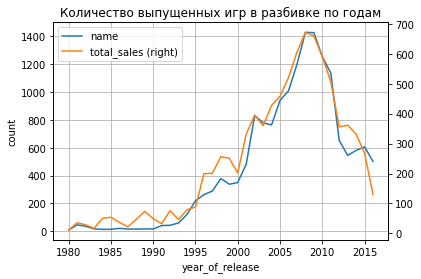

In [11]:
#количество выпущенных игр в разбивке по годам
games.groupby('year_of_release').agg({'name':'count', 'total_sales':'sum'}).plot(grid=True, 
                                                                                 secondary_y='total_sales',
                                                                                 ylabel = 'count')
plt.title('Количество выпущенных игр в разбивке по годам')
plt.show()

Количество выпущенных игр было максимальным в 2008-2009 годах и к 2013 году значительно снизилось. На графике виден резкий рост начиная с 2000 года и резкое снижение с 2009 года. Рост количества выпускаемых игр в 2000-2008 годах обьясняется ростом благополучия населения в эти годы и как следствие увеличением спроса на развлечения. Падение количества игр является последствием финансового кризиса 2008 года в части снижения спроса на развлечения. Также следует учитывать развитие технологий и увеличение доступности и популярности мобильных игр за последние годы. 

Поэтому при дальнейшем анализе данных и прогнозе на 2017 год целесообразно рассматривать информацию начиная не ранее чем с 2013 года. В этом году остановилось резкое снижение количества игр. При этом выручка от продажи игр продолжила снижаться, что может быть связано со снижением стоимости игр.

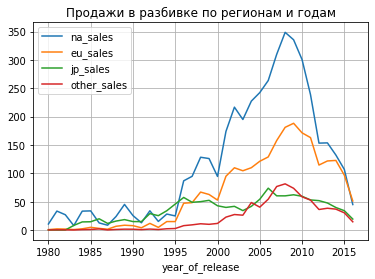

In [12]:
#продажи в разбивке по регионам и годам
games.groupby('year_of_release')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum().plot(grid=True)
plt.title('Продажи в разбивке по регионам и годам')
plt.show()

Продажи во всех регионах (за исключением Японии) имеют похожую динамику с пиком продаж в 2008-2009 годах. При этом самый большой рост продаж наблюдается в Северной Америке, самый низкий рост - в прочих странах. 
В Японии график продаж отличается от графиков всех стран - более плавный рост, нет явного пикового значения в 2008-2009 годах и более плавное снижение продаж к 2016 году. 

### Анализ сроков существавания платформ и платформы с наибольшими продажами <a id="platform_period"></a> 

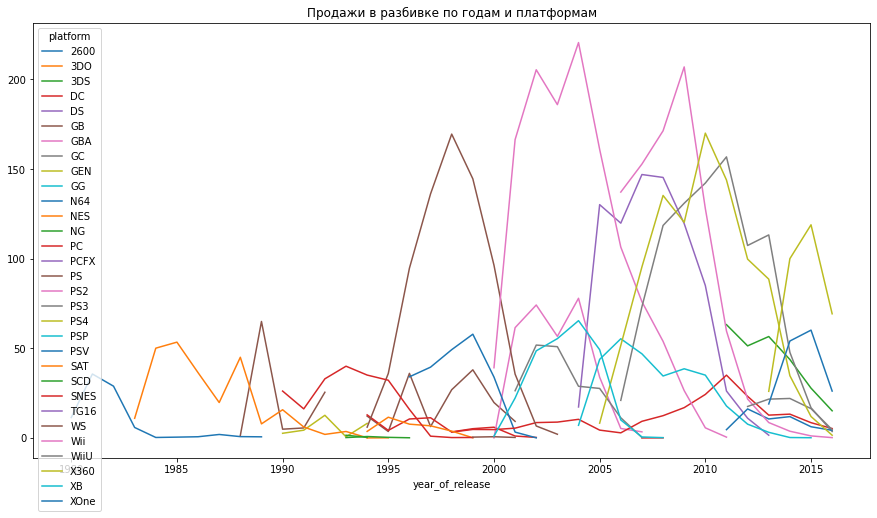

In [13]:
#продажи в разбивке по годам и платформам
pd.pivot_table(games, aggfunc='sum', values='total_sales', index='year_of_release', columns='platform').plot(figsize = (15, 8))
plt.title('Продажи в разбивке по годам и платформам')
plt.show()

На данном графике видны общие для всех платформ тенденции:
1. Срок существования каждой платформы ограничен (на графике есть момент появления и закрытия платформы) 
2. У каждой платформы есть пик (один или два) выручки и периоды роста и снижения выручки

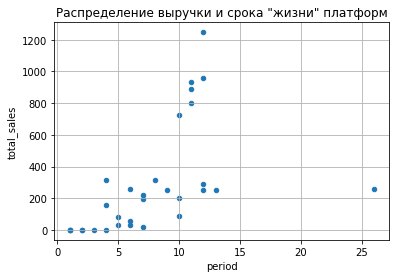

Средний период жизни платформ - 8 лет


In [14]:
#определение срока "жизни" платформ
games_platform = games.groupby(['platform', 'year_of_release'], as_index=False)['total_sales'].sum()
games_platform.columns = ['platform', 'year_of_release', 'total_sales']
games_platform['period'] = games_platform.groupby('platform')['year_of_release'].rank()

#график распределение выручки и срока "жизни" платформ
(games_platform
 .groupby('platform')
 .agg({'period':'max','total_sales':'sum'})
 .plot.scatter(x='period', y='total_sales', grid=True,)
)
plt.title('Распределение выручки и срока "жизни" платформ')
plt.show()
print('Средний период жизни платформ - {:.0f} лет'.format(games_platform.groupby('platform')['period'].max().mean()))

По суммарным продажам выделяются 6 платформ с наибольшими продажами, эти платформы имеют срок "жизни" -  10-12 лет. При среднем периоде "жизни" платформы  - 8 лет. То есть в среднем проходит 8 лет с момента появления и до закрытия платформы, при этом платформы с максимальной выручкой существуют дольше, чем другие платформы. 

,platform,total_sales
16,PS2,1247.28
28,X360,961.30
17,PS3,931.34
26,Wii,891.18
4,DS,802.79
15,PS,727.58


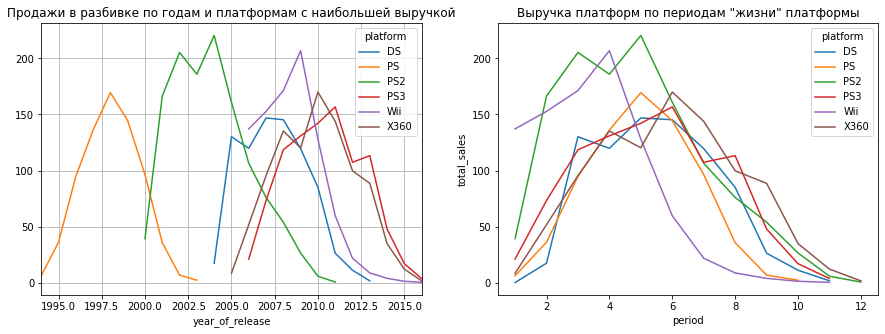

In [15]:
#платформы с наибольшими суммарными продажами
max_sales = (
    games
    .groupby(by='platform', as_index=False)['total_sales'].sum()
    .sort_values(by='total_sales', ascending=False)
    .head(6)
)
display(max_sales)

#графики продаж по годам
pd.pivot_table(games.query('platform in @max_sales.platform'), 
               aggfunc='sum', 
               values='total_sales', 
               index='year_of_release', 
               columns='platform').plot(figsize = (15, 5), xlim=(1994, 2016), grid=True, ax=plt.subplot(1,2,1))
plt.title('Продажи в разбивке по годам и платформам с наибольшей выручкой')

#графики продаж по годам и периодам существования платформ
sns.lineplot(data=games_platform.loc[games_platform['platform'].isin(max_sales['platform'])], 
             x='period', 
             y='total_sales', 
             hue='platform',
             ax=plt.subplot(1,2,2))
plt.title('Выручка платформ по периодам "жизни" платформы')
plt.show()

Из 6 платформ с максимальными продажами только 3 платформы приносят доход на конец 2016 года и на данный момент выручка этих платформ находится на спаде и приближается к 0. 

Форма графиков выручки этих платформ имеет похожую форму, с резким ростом выручки, пиком продаж на 4-6 год существования платформы и снижением выручки после 6 года.

Учитывая динамику количества выпушенных игр и выручки от продажи игр, оптимальным периодом для подробного изучения данных будет период начиная с 2013 года. В этом году остановилось резкое падение количества выпускаемых игр, что связано с стабилизацией рынка компьютерных игр. 

### Установление актуального периода <a id="act_period"></a> 

In [16]:
#установим актуальный период начиная с 2013 года
games_act = games.query('year_of_release >= 2013')
games_act.count()

name               2234
platform           2234
year_of_release    2234
genre              2234
na_sales           2234
eu_sales           2234
jp_sales           2234
other_sales        2234
critic_score        992
user_score         1193
rating             2234
total_sales        2234
dtype: int64

### Анализ динамики продаж за актуальный период <a id="act_period_analys"></a> 

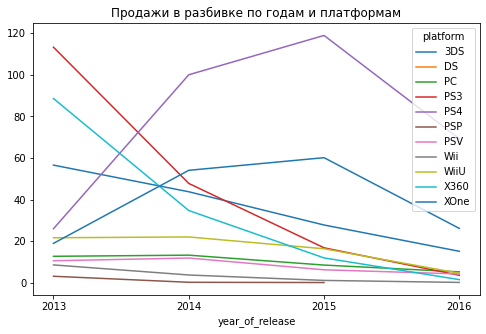

In [17]:
#графики продаж в разбивке по годам и платформам
pd.pivot_table(games_act, 
               aggfunc='sum', 
               values='total_sales', 
               index='year_of_release', 
               columns='platform').plot(figsize = (8, 5), xticks=games_act['year_of_release'].unique())
plt.title('Продажи в разбивке по годам и платформам')
plt.show()

В 2016 году выручка снизилась у всех платформ. То есть у платформ прошел пик выручки и в следующем году вероятнее всего выручка будет снижаться дальше. Но так как по условию проекта данные за 2016 год могут быть не полными, то возможно падение продаж в 2016 году не такое сильное.

Лучшие показатели по выручке в 2016 году у платформ PS4 и XOne, при этом эти платформы были запущены в 2013 году и возможно еще не достигли пика по выручке. 2017 год - это будет 5 год существования данных платформ. Пиковые значения выручки по платформам приходятся в среднем на 4-6 год существования платформы, то есть в 2017 - 2018 годах вероятнее всего выручка данных платформ будет расти.

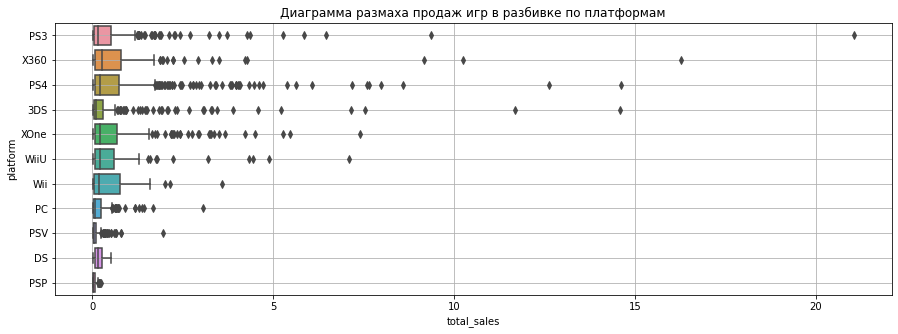

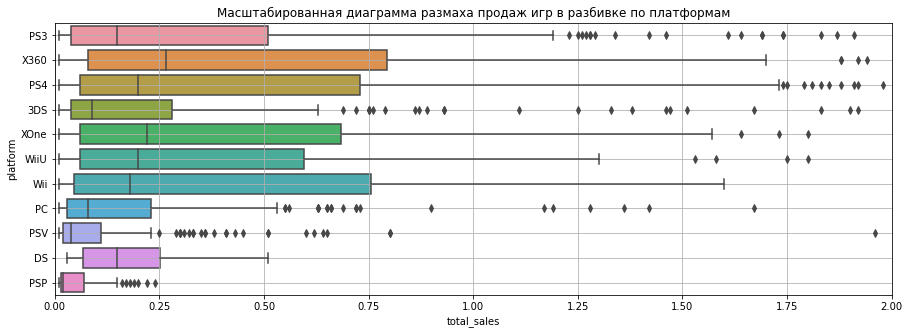

In [18]:
#график «ящик с усами» по глобальным продажам игр в разбивке по платформам
plt.figure(figsize=(15, 5))
sns.boxplot(data=games_act, x='total_sales', y='platform')
plt.title('Диаграмма размаха продаж игр в разбивке по платформам')
plt.grid()
plt.show()

#масштабированный график «ящик с усами»
plt.figure(figsize=(15, 5))
ax = sns.boxplot(data=games_act, x='total_sales', y='platform')
plt.xlim([0, 2])
plt.title('Масштабированная диаграмма размаха продаж игр в разбивке по платформам')
plt.grid()
plt.show()

Лучшую медианную выручку имеют игры на платформах Х360, XOne, WiiU и PS4. Наименьшую -  PSP и PSV. 
В целом можно заметить, что наименьший разброс выручки у наименее доходных платформ, наибольших разброс - у более доходных.

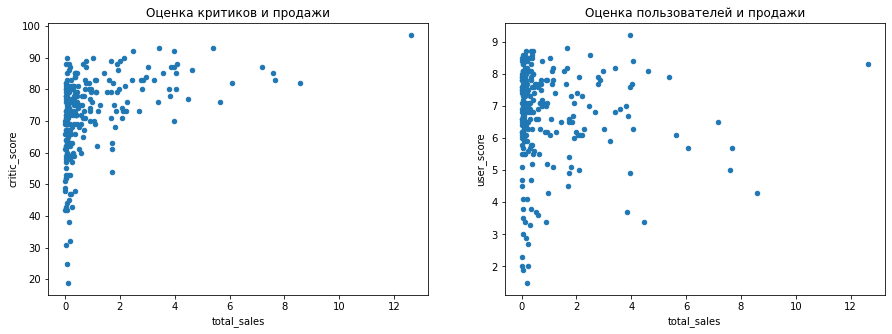

In [19]:
#диаграмма рассеяния продаж внутри платформы PS4 и отзывов пользователей и критиков
plt.figure(figsize = (15,5))
games_act.query('platform == "PS4"').plot(kind='scatter', x='total_sales', y='critic_score', ax=plt.subplot(1,2,1))
plt.title('Оценка критиков и продажи')
games_act.query('platform == "PS4"').plot(kind='scatter', x='total_sales', y='user_score', ax=plt.subplot(1,2,2))
plt.title('Оценка пользователей и продажи')
plt.show()

In [20]:
#корреляция между отзывами и продажами платформы PS4
games_act.query('platform == "PS4"')[['total_sales', 'critic_score', 'user_score']].corr()

,total_sales,critic_score,user_score
total_sales,1.000000,0.406568,-0.031957
critic_score,0.406568,1.000000,0.557654
user_score,-0.031957,0.557654,1.000000


Между суммарными продажами и оценкой пользователей нет корреляции (коэффициент корреляции - 0,02). Суммарные продажи и оценка критиков имеют низкую корреляцию (коэффициент корреляции - 0,43). 

На суммарные продажи игр платформы PS4 не повлияли отзывы и оценки пользователей, при этом оценки критиков имеют низкое влияние на суммарные продажи игр.

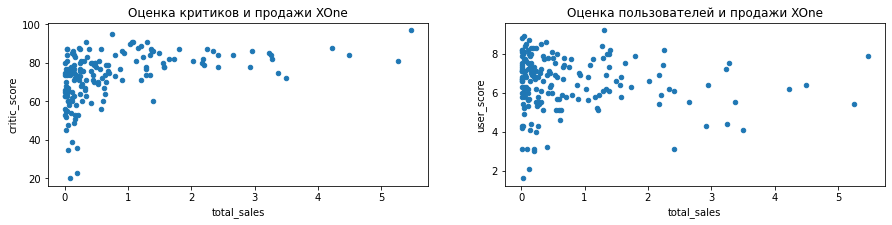

Коэффициенты корреляции XOne


,total_sales,critic_score,user_score
total_sales,1.000000,0.416998,-0.068925
critic_score,0.416998,1.000000,0.472462
user_score,-0.068925,0.472462,1.000000


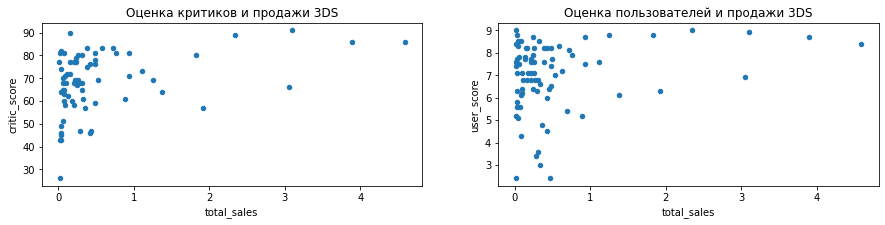

Коэффициенты корреляции 3DS


,total_sales,critic_score,user_score
total_sales,1.000000,0.357057,0.241504
critic_score,0.357057,1.000000,0.769536
user_score,0.241504,0.769536,1.000000


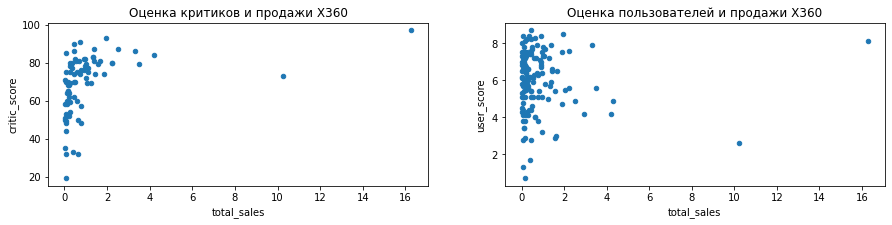

Коэффициенты корреляции X360


,total_sales,critic_score,user_score
total_sales,1.000000,0.350345,-0.011742
critic_score,0.350345,1.000000,0.520946
user_score,-0.011742,0.520946,1.000000


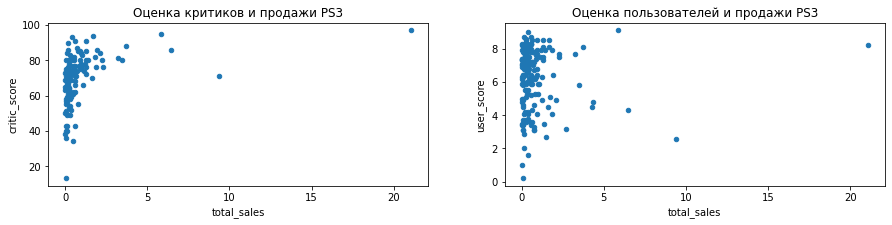

Коэффициенты корреляции PS3


,total_sales,critic_score,user_score
total_sales,1.000000,0.334285,0.002394
critic_score,0.334285,1.000000,0.599920
user_score,0.002394,0.599920,1.000000


In [21]:
#диаграммы рассеяния продаж и отзывов пользователей и критиков платформ XOne, 3DS, X360, PS3 
for platform in ['XOne', '3DS', 'X360', 'PS3']:
    plt.figure(figsize = (15, 3))
    
    games_act.query('platform == @platform').plot(kind='scatter', 
                                                   x='total_sales', 
                                                   y='critic_score', 
                                                   ax=plt.subplot(1,2,1))
    plt.title(f'Оценка критиков и продажи {platform}')
    games_act.query('platform == @platform').plot(kind='scatter', 
                                                  x='total_sales', 
                                                  y='user_score', 
                                                  ax=plt.subplot(1,2,2))
    plt.title(f'Оценка пользователей и продажи {platform}')
    plt.show()
    #корреляция между отзывами и продажами платформ 
    print(f'Коэффициенты корреляции {platform}')
    display(games_act.query('platform == @platform')[['total_sales', 'critic_score', 'user_score']].corr())
    

 Выводы почти по всем платформам похожие - есть низкая положительная корреляция между продажами и оценкой критиков и нет корреляции между продажами и оценкой пользователей. За исключением платформы 3DS  - по данной платформе есть низкая положительная корреляция между оценкой пользователей и продажами.

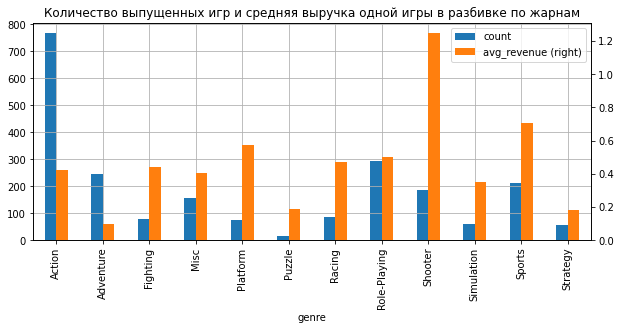

In [22]:
#общее распределение игр и средняя выручка на одну игру по жанрам 
games_genre = games_act.groupby('genre').agg({'name':'count', 'total_sales':'mean'})
games_genre.columns = ['count', 'avg_revenue']

games_genre[['count', 'avg_revenue']].plot(kind='bar', secondary_y='avg_revenue', figsize=(10,4), grid=True)
plt.title('Количество выпущенных игр и средняя выручка одной игры в разбивке по жарнам')
plt.show()

Больше всего продается игр в жанре Action, меньше всего в жанрах Puzzle, Strategy. 

Больше всего выручки на одну игру приносят жанры Shooter и Sport, меньше всего - Adventure и Puzzle.

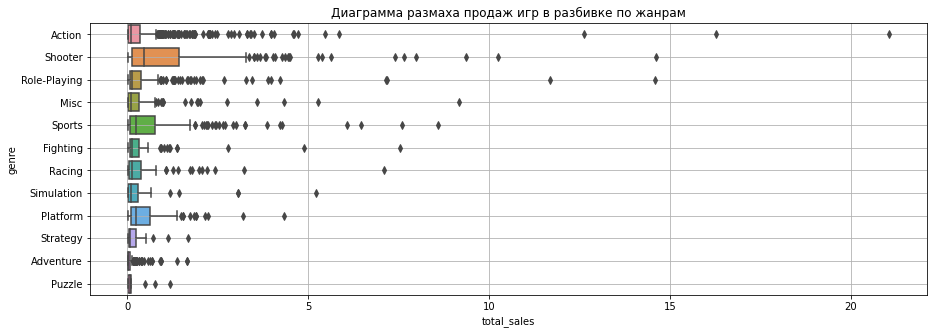

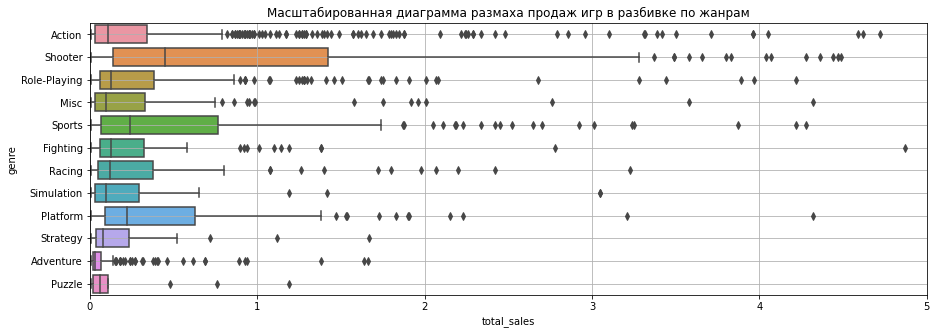

In [23]:
#диаграмма размаха продаж по платформам
plt.figure(figsize=(15, 5))
sns.boxplot(data=games_act, x='total_sales', y='genre')
plt.title('Диаграмма размаха продаж игр в разбивке по жанрам')
plt.grid()
plt.show()

#масштабированная диаграмма размаха продаж по платформам
plt.figure(figsize=(15, 5))
sns.boxplot(data=games_act, x='total_sales', y='genre')
plt.title('Масштабированная диаграмма размаха продаж игр в разбивке по жанрам')
plt.xlim([0, 5])
plt.grid()
plt.show()

 Наибольшие медианные продажи имеют игры жанров Shooter  и Sport. Наименьшие - в жанрах Adventure и Puzzle. 

## Портрет пользователя каждого региона  <a id="portrait"></a> 

In [24]:
#функция для построения графиков продаж по регионам в разбивке по самым популярным платформам 
def sales_platform_plot(region, number):
    max_sales = (
        games_act
        .groupby(by='platform', as_index=False)[region].sum()
        .sort_values(by=region, ascending=False)
        .head(5)
    ) 
    max_sales['share_sales'] = (max_sales[region]*100/ games_act[region].sum()).round(1)
   
    pd.pivot_table(games_act.query('platform in @max_sales.platform'), 
                   aggfunc='sum', 
                   values=region, 
                   index='year_of_release', 
                   columns='platform').plot(figsize = (15, 7), 
                                            grid=True, 
                                            xticks=games_act['year_of_release'].unique(),
                                            ax=plt.subplot(2, 2, number+1),
                                            xlabel='')
    plt.title(region)

In [25]:
for region in ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']:
    max_sales = (
        games_act
        .groupby(by='platform', as_index=False)[region].sum()
        .sort_values(by=region, ascending=False)
        .head(5)
    ) 
    max_sales['share_sales'] = (max_sales[region]*100/ games_act[region].sum()).round(1)
    display(max_sales)

,platform,na_sales,share_sales
4,PS4,108.74,24.8
10,XOne,93.12,21.3
9,X360,81.66,18.7
3,PS3,63.50,14.5
0,3DS,38.20,8.7


,platform,eu_sales,share_sales
4,PS4,141.09,35.9
3,PS3,67.81,17.3
10,XOne,51.59,13.1
9,X360,42.52,10.8
0,3DS,30.96,7.9


,platform,jp_sales,share_sales
0,3DS,67.81,48.2
3,PS3,23.35,16.6
6,PSV,18.59,13.2
4,PS4,15.96,11.3
8,WiiU,10.88,7.7


,platform,other_sales,share_sales
4,PS4,48.35,40.3
3,PS3,26.77,22.3
10,XOne,14.27,11.9
9,X360,12.11,10.1
0,3DS,6.28,5.2


Структура и динамика продаж по платформам в Европе и прочих странах практически идентична. Лидирующие позиции имеет платформа PS4, на второй позиции - PS3. 

В Северной Америке также лидирует платформа PS4, но на втором месте X360. Это связано с тем, что XOne выпускает американская компания Microsoft. Поэтому X360 более популярна в Северной Америке, чем в Европе.

В Японии самая популярная платформа - 3DS(Nintendo, Япония). Особенностью структуры продаж в Японии является то, что все топ-5 популярных платформ произведены японскими компаниями. В топ-5 не вошли платформы компании Microsoft.

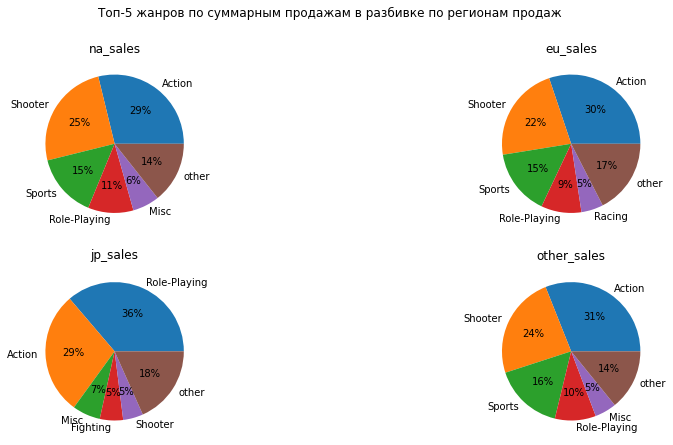

In [26]:
#самые популярные жанры (топ-5) в разбивке по регионам
fig, ax = plt.subplots(figsize = (15, 7))
for i, region in enumerate(['na_sales', 'eu_sales', 'jp_sales', 'other_sales']):
    genre_share = games_act.groupby('genre')[region].sum().sort_values(ascending=False).head(5)
    genre_share.loc['other'] = games_act[region].sum() - genre_share.sum()
    genre_share.plot.pie(ax=plt.subplot(2, 2, i + 1), 
                         grid=True, xlabel='', ylabel='', 
                         autopct='%1.0f%%')
    plt.title(region)
fig.suptitle('Топ-5 жанров по суммарным продажам в разбивке по регионам продаж')
plt.show()

Северная Америка, Европа и прочие страны имеют похожее распределение по популярности жанров. Лидируют жанры Action и Shooter. 

В Японии наибольшей популярностью пользуются Role-Playing и Action. Shooter находится только на 5 месте. 
Интересно, что жанр Sports находится на третьем месте по полулярности в Северной Америке и прочих странах, но не входит в топ-5 жанров в Японии. 

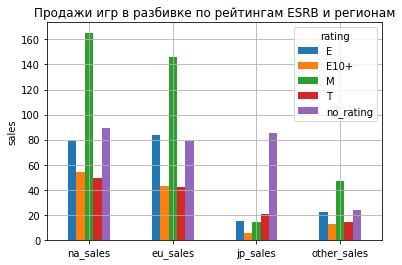

In [27]:
#продажи в разбивке по рейтингу ESRB и регионам
(
    games_act.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']]
             .sum()
             .transpose()
             .plot.bar(grid=True, ylabel='sales')
)
plt.title('Продажи игр в разбивке по рейтингам ESRB и регионам')
plt.xticks(rotation = 0)
plt.show()

Распределение продаж по рейтингам ESRB в Северной Америке, Европе и прочих странах имеет похожую форму. Максимальные продажи приносят игры с рейтингом M, затем игры без рейтинга и игры с рейтингом Е. 

Распределение продаж по рейтингу игр в Японии отличается тем, что максимальные продажи (с большим преимуществом) приносят игры без рейтинга, затем игры с рейтингом Т. 


In [28]:
#проверка наличия коррелиции между продажами и рейтингом
#перекодируем рейтинг в числовое значение
games_act['rating_cat'] = games_act['rating'].astype('category').cat.codes
games_act[['rating_cat', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales']].corr()

/tmp/ipykernel_559/1674200503.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_act['rating_cat'] = games_act['rating'].astype('category').cat.codes


,rating_cat,na_sales,eu_sales,jp_sales,other_sales
rating_cat,1.000000,-0.147564,-0.155884,0.084144,-0.135658
na_sales,-0.147564,1.000000,0.769964,0.264535,0.817364
eu_sales,-0.155884,0.769964,1.000000,0.244594,0.934785
jp_sales,0.084144,0.264535,0.244594,1.000000,0.195198
other_sales,-0.135658,0.817364,0.934785,0.195198,1.000000


Корреляции между рейтингом и продажами нет.

## Проверка гипотез   <a id="hypothesis"></a> 

### Гипотеза 1: средние пользовательские рейтинги платформ Xbox One и PC одинаковые   <a id="hypothesis_one"></a> 


Нулевая гипотеза: средние пользовательские рейтинги платформ Xbox One и PS4 одинаковые

Альтернативная гипотеза: средние пользовательские рейтинги платформ Xbox One и PS4 разные

In [29]:
alpha = .01

sample_1 = games_act.loc[games_act['platform'].str.contains("PS4") & games_act['user_score'].notnull()]['user_score']
sample_2 = games_act.loc[games_act['platform'].str.contains("XOne") & games_act['user_score'].notnull()]['user_score']
print('Размер выборки PS4', sample_1.count())
print('Размер выборки Xbox One', sample_2.count())

results = st.ttest_ind(sample_1, sample_2, equal_var = False)

print('p-значение: ', results.pvalue)

if results.pvalue < alpha: 
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Размер выборки PS4 257
Размер выборки Xbox One 182
p-значение:  0.09855299487302606
Не получилось отвергнуть нулевую гипотезу


Для проверки гипотезы используем метод st.ttest_ind, так как мы сравниваем средние значения двух
генеральных совокупностей по взятым из них выборкам. Так как выборки разного размера, укажем параметр equal_var = False. 

Таким образом в результате проверки нулевая гипотеза не отвергнута в пользу альтернативной. То есть средние пользовательские рейтинги платформ Xbox One и PS4 одинаковые.

### Гипотеза 2: средние пользовательские рейтинги жанров Action  и Sports  разные <a id="hypothesis_two"></a> 

Нулевая гипотеза: средние пользовательские рейтинги жанров Action и Sports одинаковые


Альтернативная гипотеза: средние пользовательские рейтинги жанров Action и Sports разные

In [30]:
alpha = .01

sample_3 = games_act.query('genre == "Action" & user_score == user_score')['user_score']
sample_4 = games_act.query('genre == "Sports" & user_score == user_score')['user_score']

print('Размер выборки жанр Action', sample_3.count())
print('Размер выборки жанр Sports', sample_4.count())

results = st.ttest_ind(sample_3, sample_4, equal_var = False)


print('p-значение: ', results.pvalue)

if results.pvalue < alpha: 
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

print('Средний пользовательский рейтинг игр жанра Action', round(sample_3.mean(), 2))
print('Средний пользовательский рейтинг игр жанра Sports', round(sample_4.mean(), 2))

Размер выборки жанр Action 390
Размер выборки жанр Sports 160
p-значение:  1.1834440653354691e-20
Отвергаем нулевую гипотезу
Средний пользовательский рейтинг игр жанра Action 6.84
Средний пользовательский рейтинг игр жанра Sports 5.24


Для проверки гипотезы используем метод st.ttest_ind, так как мы сравниваем средние значения двух
генеральных совокупностей по взятым из них выборкам. Так как выборки разного размера, укажем параметр equal_var = False.  

Таким образом на имеющихся данных, на уровне значимости 1% есть основания отвергнуть нулевую гипотезу о равенстве средних значений пользовательских рейтингов (отзывов) жанров Action и Sports в пользу альтернативной гипотезы.

## Общий вывод <a id="conclusion"></a> 

При планировании рекламных кампаний на 2017 год и поиске потенциально популярного продукта необходимо учитывать следующие факторы:

1. Наиболее перспективные платформы по ожидаемому росту продаж - XOne и PS4. Пиковые значения выручки по платформам приходятся в среднем на 4-6 год существования платформы, то есть в 2017 - 2018 годах вероятнее всего выручка данных платформ будет расти.
2. Лучшую медианную выручку имеют игры на платформах Х360, XOne и PS4. 
3. Больше всего выпущено игр в жанре Action, но больше дохода на одну игру приносит жанр Shooter.
4. Продажи по регионам имеют различное распределение по жанрам и платформам. В Японии потенциально успешными будут игры в жанрах Role-Playing и Action на платформе 3DS (либо на новой платформе Nintendo). В Северной Америке - в жанрах Action и Shooter на платформах PS4 и X360. В Европе и прочих странах - в жанрах Action и Shooter на платформах PS4 и PS3. 
5. Корреляции между рейтингом игры и продажами нет. Но можно заметить, что во всех странах кроме Японии больше всего дохода приносят игры с рейтингом М, в Японии - игры без рейтинга. 
6. Корреляции между пользовательскими рейтингами и объемами продаж нет.
7. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые.
8. Средние пользовательские рейтинги жанров Action и Sports разные.